# 14 — Classificação: Desempenho no ENEM × Fatores Socioeconômicos

**Pré-requisito:** rodar notebook 15 para gerar `ml_features.parquet`, `test_set.parquet` e `val_set.parquet`.

**Target:** `FAIXA_3C` — 3 classes:
| Classe | Notas MT |
|--------|----------|
| `Baixo` | < 500 |
| `Medio` | 500 – 700 |
| `Alto`  | ≥ 700 |

**Variantes de feature set:**
| Variante | Features |
|----------|----------|
| M1 | ENEM individual (28 features) |
| M2 | M1 + IDHM agregado por UF (37) |
| M3 | M2 + IDHM personalizado por raça/sexo (39) |

**Algoritmos (AG otimiza LR, SVM, LGB, HGB):**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. HistGradientBoosting (HGB)
5. SVM (LinearSVC)
6. LightGBM
7. Ensemble SVM+LGB — Hard Voting
8. Ensemble SVM+LGB — Soft Voting
9. Ensemble Top-2 — Soft Voting (dinâmico)
10. Ensemble Full — Soft Voting (todos os 6 modelos base)

## 0. Imports e configuração

In [1]:
import warnings, time, gc
warnings.filterwarnings('ignore')

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import LinearSVC
from sklearn.calibration   import CalibratedClassifierCV
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                   HistGradientBoostingClassifier,
                                   VotingClassifier)
from sklearn.pipeline      import Pipeline
from sklearn.impute        import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import (classification_report, accuracy_score,
                                   f1_score, ConfusionMatrixDisplay)
from pathlib import Path

BASE         = Path('../data/processed')
ML_PARQUET   = BASE / 'ml_features.parquet'
TEST_SET     = BASE / 'test_set.parquet'
VAL_SET      = BASE / 'val_set.parquet'
SEED         = 42
SAMPLE_TRAIN = 1_000_000
CLASS_3      = ['Baixo', 'Medio', 'Alto']

FEATS_M1 = [
    'REGIAO_NUM', 'TP_SEXO_NUM', 'TP_COR_RACA_NUM', 'TP_ESCOLA_NUM',
    'Q001_NUM', 'Q002_NUM', 'Q006_NUM',
    'Q_N_PESSOAS_NUM', 'Q_OCUP_PAI_NUM', 'Q_OCUP_MAE_NUM',
    'Q_EMPREGADA_NUM', 'Q_BANHEIRO_NUM', 'Q_QUARTO_NUM',
    'Q_CARRO_NUM', 'Q_MOTO_NUM', 'Q_GELADEIRA_NUM',
    'Q_FREEZER_NUM', 'Q_LAVADORA_NUM', 'Q_MICROONDAS_NUM', 'Q_IMPRESSORA_NUM',
    'Q_TV_NUM', 'Q_COMPUTADOR_NUM', 'Q_INTERNET_NUM', 'Q_CELULAR_NUM', 'Q_TEL_FIXO_NUM',
    'Q_TIPO_ESCOLA_EM_NUM', 'Q_BOLSA_FAM_NUM', 'Q_TRABALHA_NUM',
]
FEATS_IDHM = [
    'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_longevidade',
    'renda_percapita', 'tx_analfabetismo', 'tx_envelhecimento',
    'esperanca_vida', 'mortalidade_infantil',
]
FEATS_PERS = ['idhm_cand_raca', 'idhm_cand_sexo']

FEATS_M2 = FEATS_M1 + FEATS_IDHM
FEATS_M3 = FEATS_M2 + FEATS_PERS

VARIANTS = {'M1': FEATS_M1, 'M2': FEATS_M2, 'M3': FEATS_M3}

print(f'M1: {len(FEATS_M1)} | M2: {len(FEATS_M2)} | M3: {len(FEATS_M3)} features')

M1: 28 | M2: 37 | M3: 39 features


## 1. Carregamento dos dados

- Val e Teste: carregados dos arquivos fixos gerados pelo notebook 15
- Treino: anti-join nos IDs de teste/val, depois amostra 1M linhas

In [2]:
MAP_3C = {
    '<400': 'Baixo', '400-500': 'Baixo',
    '500-600': 'Medio', '600-700': 'Medio',
    '700-800': 'Alto', '>800': 'Alto',
}

# Val e Teste — fixos
df_val  = pd.read_parquet(VAL_SET)
df_test = pd.read_parquet(TEST_SET)

df_val['FAIXA_3C']  = df_val['FAIXA_MT'].map(MAP_3C)
df_test['FAIXA_3C'] = df_test['FAIXA_MT'].map(MAP_3C)

# IDs a excluir do treino
excl_ids = pd.concat([
    df_val[['_row_id']],
    df_test[['_row_id']],
])

# Treino: anti-join + amostra 1M
con = duckdb.connect()
con.execute("SET memory_limit = '8GB'")
con.register('excl_ids', excl_ids)

df_train = con.execute(f"""
    SELECT *
    FROM read_parquet('{ML_PARQUET}')
    WHERE FAIXA_MT IS NOT NULL
      AND NU_ANO BETWEEN 2019 AND 2024
      AND _row_id NOT IN (SELECT _row_id FROM excl_ids)
    USING SAMPLE {SAMPLE_TRAIN} (reservoir, {SEED})
""").df()
con.close()

df_train['FAIXA_3C'] = df_train['FAIXA_MT'].map(MAP_3C)

print(f'Treino:  {len(df_train):>10,} linhas')
print(f'Val:     {len(df_val):>10,} linhas')
print(f'Teste:   {len(df_test):>10,} linhas (SELADO)')

print('\nDistribuição treino:')
print(df_train['FAIXA_3C'].value_counts(normalize=True).reindex(CLASS_3)
      .apply(lambda x: f'{x:.1%}'))

Treino:     260,933 linhas
Val:      1,488,771 linhas
Teste:    1,654,191 linhas (SELADO)

Distribuição treino:
FAIXA_3C
Baixo    46.6%
Medio    44.3%
Alto      9.0%
Name: proportion, dtype: str


In [3]:
# Arrays por variante
TARGET = 'FAIXA_3C'

arrays = {}
for vname, feats in VARIANTS.items():
    X_tr = df_train[feats].astype('float64').values
    X_v  = df_val[feats].astype('float64').values
    X_te = df_test[feats].astype('float64').values
    arrays[vname] = (X_tr, X_v, X_te)
    nan_pct = np.isnan(X_tr).mean() * 100
    print(f'{vname}: {X_tr.shape}  NaN médio={nan_pct:.1f}%')

y_train = df_train[TARGET].values
y_val   = df_val[TARGET].values
y_test  = df_test[TARGET].values

M1: (260933, 28)  NaN médio=4.1%
M2: (260933, 37)  NaN médio=20.5%
M3: (260933, 39)  NaN médio=23.2%


## 2. Algoritmo Genético — otimização de hiperparâmetros

Implementação real-valued sem bibliotecas externas (igual ao notebook 07).  
Fitness avaliado num **subset de 30k amostras** do treino para velocidade.

| Modelo | Gene 0 | Gene 1 | pop / gens |
|--------|--------|--------|------------|
| LR | log₁₀(C) ∈ [-3,2] | class_weight {0,1} | 20/15 |
| SVM | log₁₀(C) ∈ [-3,2] | class_weight {0,1} | 20/15 |
| LGB | learning_rate ∈ [0.01,0.3] | num_leaves ∈ [15,127] | 15/10 |
| HGB | learning_rate ∈ [0.01,0.3] | max_depth ∈ [3,12] | 15/10 |

In [4]:
# ── Subset para fitness ───────────────────────────────────────────────────────
GA_SUB = 30_000
rng_sub = np.random.default_rng(SEED)

X_m1_tr = arrays['M1'][0]
idx_sub  = rng_sub.choice(len(X_m1_tr), size=min(GA_SUB, len(X_m1_tr)), replace=False)
idx_subv = rng_sub.choice(len(arrays['M1'][1]), size=min(10_000, len(arrays['M1'][1])), replace=False)

X_sub,    y_sub    = X_m1_tr[idx_sub],           y_train[idx_sub]
X_subval, y_subval = arrays['M1'][1][idx_subv],  y_val[idx_subv]

print(f'Subset treino AG: {len(X_sub):,} | Subset val AG: {len(X_subval):,}')

# ── Operadores genéticos genéricos ────────────────────────────────────────────
def _tournament(pop, fits, k, rng):
    idx = rng.integers(0, len(pop), k)
    return pop[idx[np.argmax(fits[idx])]].copy()

def _crossover(p1, p2, rng):
    mask = rng.random(len(p1)) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)

def _mutate(ind, gene_min, gene_max, binary_mask, rng):
    ind = ind.copy()
    ranges = gene_max - gene_min
    for i in range(len(ind)):
        if binary_mask[i]:
            if rng.random() < 0.30: ind[i] = 1.0 - ind[i]
        else:
            if rng.random() < 0.40:
                ind[i] = np.clip(ind[i] + rng.normal(0, 0.15 * ranges[i]),
                                 gene_min[i], gene_max[i])
    return ind

def evolve_ag(gene_min, gene_max, fitness_fn, binary_mask,
              pop_size=20, n_gens=15, seed=SEED, label=''):
    rng  = np.random.default_rng(seed)
    # Inicialização
    pop  = np.column_stack([rng.uniform(gene_min[i], gene_max[i], pop_size)
                            for i in range(len(gene_min))])
    # Binarizar genes binários na inicialização
    for i, b in enumerate(binary_mask):
        if b: pop[:, i] = np.round(pop[:, i])
    fits = np.array([fitness_fn(ind) for ind in pop])
    hist = [fits.max()]
    print(f'[{label}] Gen  0  best={fits.max():.4f}  mean={fits.mean():.4f}')

    for gen in range(1, n_gens + 1):
        elite   = list(pop[np.argsort(fits)[-2:]])
        new_pop = elite[:]
        while len(new_pop) < pop_size:
            p1 = _tournament(pop, fits, 3, rng)
            p2 = _tournament(pop, fits, 3, rng)
            c1, c2 = (_crossover(p1, p2, rng) if rng.random() < 0.70
                      else (p1.copy(), p2.copy()))
            if rng.random() < 0.25: c1 = _mutate(c1, gene_min, gene_max, binary_mask, rng)
            if rng.random() < 0.25: c2 = _mutate(c2, gene_min, gene_max, binary_mask, rng)
            new_pop.append(c1)
            if len(new_pop) < pop_size: new_pop.append(c2)
        pop  = np.array(new_pop)
        fits = np.array([fitness_fn(ind) for ind in pop])
        hist.append(fits.max())
        print(f'[{label}] Gen {gen:2d}  best={fits.max():.4f}  mean={fits.mean():.4f}')

    return pop[fits.argmax()], fits.max(), hist

print('Componentes do AG definidos.')

Subset treino AG: 30,000 | Subset val AG: 10,000
Componentes do AG definidos.


In [5]:
# ── AG para Logistic Regression ───────────────────────────────────────────────
def decode_lr(ind):
    return float(10 ** np.clip(ind[0], -3, 2)), bool(round(np.clip(ind[1], 0, 1)))

def fitness_lr(ind):
    C, bal = decode_lr(ind)
    try:
        m = Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('scl', StandardScaler()),
                      ('clf', LogisticRegression(C=C,
                          class_weight='balanced' if bal else None,
                          max_iter=300, solver='saga', n_jobs=-1, random_state=SEED))])
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro',
                        labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — Logistic Regression ===')
t0 = time.time()
best_lr_ind, _, ag_hist_lr = evolve_ag(
    np.array([-3.0, 0.0]), np.array([2.0, 1.0]),
    fitness_lr, binary_mask=[False, True],
    pop_size=20, n_gens=15, label='LR')
best_C_lr, best_bal_lr = decode_lr(best_lr_ind)
print(f'\nResultado: C={best_C_lr:.4f}, balanced={best_bal_lr}  ({(time.time()-t0)/60:.1f} min)')

=== AG — Logistic Regression ===
[LR] Gen  0  best=0.4367  mean=0.4268
[LR] Gen  1  best=0.4367  mean=0.4330
[LR] Gen  2  best=0.4367  mean=0.4327
[LR] Gen  3  best=0.4367  mean=0.4331
[LR] Gen  4  best=0.4367  mean=0.4327
[LR] Gen  5  best=0.4370  mean=0.4366
[LR] Gen  6  best=0.4370  mean=0.4366
[LR] Gen  7  best=0.4370  mean=0.4347
[LR] Gen  8  best=0.4370  mean=0.4361
[LR] Gen  9  best=0.4370  mean=0.4369
[LR] Gen 10  best=0.4370  mean=0.4360
[LR] Gen 11  best=0.4370  mean=0.4350
[LR] Gen 12  best=0.4370  mean=0.4357
[LR] Gen 13  best=0.4370  mean=0.4370
[LR] Gen 14  best=0.4370  mean=0.4368
[LR] Gen 15  best=0.4370  mean=0.4368

Resultado: C=0.0022, balanced=True  (3.2 min)


In [6]:
# ── AG para SVM (LinearSVC) ───────────────────────────────────────────────────
def decode_svm(ind):
    return float(10 ** np.clip(ind[0], -3, 2)), bool(round(np.clip(ind[1], 0, 1)))

def fitness_svm(ind):
    C, bal = decode_svm(ind)
    try:
        m = Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('scl', StandardScaler()),
                      ('clf', LinearSVC(C=C,
                          class_weight='balanced' if bal else None,
                          max_iter=2000, random_state=SEED))])
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro',
                        labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — SVM (LinearSVC) ===')
t0 = time.time()
best_svm_ind, _, ag_hist_svm = evolve_ag(
    np.array([-3.0, 0.0]), np.array([2.0, 1.0]),
    fitness_svm, binary_mask=[False, True],
    pop_size=20, n_gens=15, label='SVM')
best_C_svm, best_bal_svm = decode_svm(best_svm_ind)
print(f'\nResultado: C={best_C_svm:.4f}, balanced={best_bal_svm}  ({(time.time()-t0)/60:.1f} min)')

=== AG — SVM (LinearSVC) ===
[SVM] Gen  0  best=0.4792  mean=0.4310
[SVM] Gen  1  best=0.4793  mean=0.4671
[SVM] Gen  2  best=0.4793  mean=0.4631
[SVM] Gen  3  best=0.4793  mean=0.4672
[SVM] Gen  4  best=0.4793  mean=0.4632
[SVM] Gen  5  best=0.4793  mean=0.4792
[SVM] Gen  6  best=0.4793  mean=0.4792
[SVM] Gen  7  best=0.4793  mean=0.4712
[SVM] Gen  8  best=0.4793  mean=0.4753
[SVM] Gen  9  best=0.4793  mean=0.4793
[SVM] Gen 10  best=0.4793  mean=0.4752
[SVM] Gen 11  best=0.4793  mean=0.4712
[SVM] Gen 12  best=0.4794  mean=0.4753
[SVM] Gen 13  best=0.4794  mean=0.4793
[SVM] Gen 14  best=0.4794  mean=0.4793
[SVM] Gen 15  best=0.4794  mean=0.4794

Resultado: C=0.0022, balanced=True  (2.5 min)


In [7]:
# ── AG para LightGBM ──────────────────────────────────────────────────────────
def decode_lgb(ind):
    lr         = float(np.clip(ind[0], 0.01, 0.30))
    num_leaves = int(round(np.clip(ind[1], 15, 127)))
    return lr, num_leaves

def fitness_lgb(ind):
    lr, nl = decode_lgb(ind)
    try:
        m = lgb.LGBMClassifier(learning_rate=lr, num_leaves=nl,
                                n_estimators=200, max_depth=8,
                                n_jobs=-1, random_state=SEED, verbose=-1)
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro',
                        labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — LightGBM ===')
t0 = time.time()
best_lgb_ind, _, ag_hist_lgb = evolve_ag(
    np.array([0.01, 15.0]), np.array([0.30, 127.0]),
    fitness_lgb, binary_mask=[False, False],
    pop_size=15, n_gens=10, label='LGB')
best_lr_lgb, best_nl_lgb = decode_lgb(best_lgb_ind)
print(f'\nResultado: lr={best_lr_lgb:.4f}, num_leaves={best_nl_lgb}  ({(time.time()-t0)/60:.1f} min)')

=== AG — LightGBM ===
[LGB] Gen  0  best=0.4651  mean=0.4592
[LGB] Gen  1  best=0.4651  mean=0.4621
[LGB] Gen  2  best=0.4684  mean=0.4623
[LGB] Gen  3  best=0.4684  mean=0.4655
[LGB] Gen  4  best=0.4684  mean=0.4670
[LGB] Gen  5  best=0.4684  mean=0.4662
[LGB] Gen  6  best=0.4684  mean=0.4677
[LGB] Gen  7  best=0.4684  mean=0.4676
[LGB] Gen  8  best=0.4684  mean=0.4672
[LGB] Gen  9  best=0.4684  mean=0.4658
[LGB] Gen 10  best=0.4684  mean=0.4679

Resultado: lr=0.1967, num_leaves=26  (3.3 min)


In [8]:
# ── AG para HistGradientBoosting (HGB) ────────────────────────────────────────
def decode_hgb(ind):
    lr        = float(np.clip(ind[0], 0.01, 0.30))
    max_depth = int(round(np.clip(ind[1], 3, 12)))
    return lr, max_depth

def fitness_hgb(ind):
    lr, md = decode_hgb(ind)
    try:
        m = HistGradientBoostingClassifier(learning_rate=lr, max_depth=md,
                                           max_iter=200, min_samples_leaf=50,
                                           random_state=SEED)
        m.fit(X_sub, y_sub)
        return f1_score(y_subval, m.predict(X_subval), average='macro',
                        labels=CLASS_3, zero_division=0)
    except Exception: return 0.0

print('=== AG — HistGradientBoosting ===')
t0 = time.time()
best_hgb_ind, _, ag_hist_hgb = evolve_ag(
    np.array([0.01,  3.0]), np.array([0.30, 12.0]),
    fitness_hgb, binary_mask=[False, False],
    pop_size=15, n_gens=10, label='HGB')
best_lr_hgb, best_md_hgb = decode_hgb(best_hgb_ind)
print(f'\nResultado: lr={best_lr_hgb:.4f}, max_depth={best_md_hgb}  ({(time.time()-t0)/60:.1f} min)')

=== AG — HistGradientBoosting ===
[HGB] Gen  0  best=0.4582  mean=0.4477
[HGB] Gen  1  best=0.4614  mean=0.4519
[HGB] Gen  2  best=0.4641  mean=0.4570
[HGB] Gen  3  best=0.4641  mean=0.4601
[HGB] Gen  4  best=0.4641  mean=0.4618
[HGB] Gen  5  best=0.4641  mean=0.4626
[HGB] Gen  6  best=0.4641  mean=0.4638
[HGB] Gen  7  best=0.4641  mean=0.4631
[HGB] Gen  8  best=0.4647  mean=0.4631
[HGB] Gen  9  best=0.4647  mean=0.4631
[HGB] Gen 10  best=0.4647  mean=0.4641

Resultado: lr=0.2999, max_depth=8  (1.0 min)


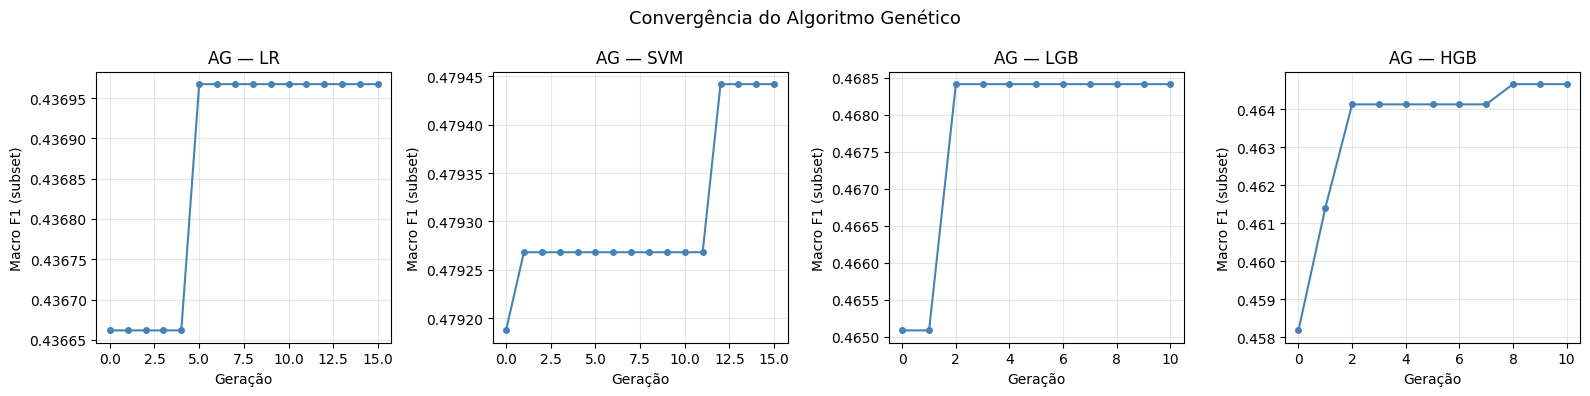

In [9]:
# Plot de convergência do AG
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, (nome, hist) in zip(axes, [
    ('LR', ag_hist_lr), ('SVM', ag_hist_svm),
    ('LGB', ag_hist_lgb), ('HGB', ag_hist_hgb)
]):
    ax.plot(range(len(hist)), hist, 'o-', color='steelblue', markersize=4)
    ax.set_title(f'AG — {nome}')
    ax.set_xlabel('Geração')
    ax.set_ylabel('Macro F1 (subset)')
    ax.grid(True, alpha=0.3)
plt.suptitle('Convergência do Algoritmo Genético', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/ag_convergencia.png', dpi=120)
plt.show()

## 3. Definição dos modelos com hiperparâmetros do AG

In [10]:
_imp = lambda: SimpleImputer(strategy='median')
_scl = lambda: StandardScaler()

# ── Modelos base ──────────────────────────────────────────────────────────────
modelos_base = {
    'LogisticRegression': Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', LogisticRegression(
            C=best_C_lr,
            class_weight='balanced' if best_bal_lr else None,
            max_iter=500, solver='saga', n_jobs=-1, random_state=SEED)),
    ]),
    'DecisionTree': Pipeline([
        ('imp', _imp()),
        ('clf', DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, random_state=SEED)),
    ]),
    'RandomForest': Pipeline([
        ('imp', _imp()),
        ('clf', RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_leaf=50,
            n_jobs=-1, random_state=SEED)),
    ]),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=best_lr_hgb, max_depth=best_md_hgb,
        max_iter=200, min_samples_leaf=50, random_state=SEED,
    ),
    'SVM (LinearSVC)': Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', LinearSVC(
            C=best_C_svm,
            class_weight='balanced' if best_bal_svm else None,
            max_iter=3000, random_state=SEED)),
    ]),
    'LightGBM': lgb.LGBMClassifier(
        learning_rate=best_lr_lgb, num_leaves=best_nl_lgb,
        n_estimators=300, max_depth=8, n_jobs=-1, random_state=SEED, verbose=-1,
    ),
}

# ── SVM calibrado para soft voting ────────────────────────────────────────────
def make_cal_svm():
    return Pipeline([
        ('imp', _imp()), ('scl', _scl()),
        ('clf', CalibratedClassifierCV(
            LinearSVC(C=best_C_svm,
                      class_weight='balanced' if best_bal_svm else None,
                      max_iter=3000, random_state=SEED), cv=3)),
    ])

def make_lgb_clone():
    return lgb.LGBMClassifier(
        learning_rate=best_lr_lgb, num_leaves=best_nl_lgb,
        n_estimators=300, max_depth=8, n_jobs=-1, random_state=SEED, verbose=-1)

def make_rf_clone():
    return Pipeline([('imp', _imp()),
                     ('clf', RandomForestClassifier(n_estimators=100, max_depth=15,
                                                    min_samples_leaf=50, n_jobs=-1,
                                                    random_state=SEED))])

def make_hgb_clone():
    return HistGradientBoostingClassifier(learning_rate=best_lr_hgb, max_depth=best_md_hgb,
                                          max_iter=200, min_samples_leaf=50, random_state=SEED)

# ── Ensembles fixos ───────────────────────────────────────────────────────────
ensembles_fixos = {
    'Ensemble SVM+LGB Hard': VotingClassifier(
        estimators=[('svm', make_cal_svm()), ('lgb', make_lgb_clone())],
        voting='hard', n_jobs=1,
    ),
    'Ensemble SVM+LGB Soft': VotingClassifier(
        estimators=[('svm', make_cal_svm()), ('lgb', make_lgb_clone())],
        voting='soft', n_jobs=1,
    ),
    'Ensemble Full Soft': VotingClassifier(
        estimators=[
            ('svm', make_cal_svm()), ('lgb', make_lgb_clone()),
            ('rf',  make_rf_clone()), ('hgb', make_hgb_clone()),
        ],
        voting='soft', n_jobs=1,
    ),
}

print(f'Modelos base: {list(modelos_base.keys())}')
print(f'Ensembles: {list(ensembles_fixos.keys())}')
print('\n[Ensemble Top-2 Soft será definido dinamicamente após M1]')

Modelos base: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'SVM (LinearSVC)', 'LightGBM']
Ensembles: ['Ensemble SVM+LGB Hard', 'Ensemble SVM+LGB Soft', 'Ensemble Full Soft']

[Ensemble Top-2 Soft será definido dinamicamente após M1]


## 4. Loop de treinamento × M1 / M2 / M3

In [11]:
from sklearn.base import clone

all_results       = []
all_trained       = {}   # (nome, variante) → modelo treinado
top2_ensemble     = None
top2_names        = None

for vname, feats in VARIANTS.items():
    X_tr, X_v, X_te = arrays[vname]
    print(f'\n{'='*60}')
    print(f'  Variante {vname} — {len(feats)} features')
    print(f'{'='*60}')

    # Clona modelos para cada variante (evita contaminação entre variantes)
    modelos_v = {n: clone(m) for n, m in modelos_base.items()}

    # Adiciona ensembles (novos objetos por variante)
    modelos_v.update({n: clone(m) for n, m in ensembles_fixos.items()})

    # Ensemble Top-2: criado após M1, reutilizado (re-clonado) em M2/M3
    if top2_ensemble is not None:
        modelos_v['Ensemble Top-2 Soft'] = clone(top2_ensemble)

    f1_scores_v = {}

    for nome, modelo in modelos_v.items():
        print(f'  {nome}...', end=' ', flush=True)
        t0 = time.time()
        modelo.fit(X_tr, y_train)
        t_tr = time.time() - t0

        y_pred = modelo.predict(X_v)
        acc  = accuracy_score(y_val, y_pred)
        f1_w = f1_score(y_val, y_pred, average='weighted', labels=CLASS_3, zero_division=0)
        f1_m = f1_score(y_val, y_pred, average='macro',    labels=CLASS_3, zero_division=0)

        all_results.append({'Variante': vname, 'Modelo': nome,
                            'Acurácia': acc, 'F1 Weighted': f1_w,
                            'F1 Macro': f1_m, 'Tempo (s)': round(t_tr, 1)})
        all_trained[(nome, vname)] = modelo
        f1_scores_v[nome] = f1_m
        print(f'acc={acc:.3f}  F1m={f1_m:.3f}  F1w={f1_w:.3f}  ({t_tr:.0f}s)')

    # Cria Ensemble Top-2 após a primeira variante (M1)
    if vname == 'M1' and top2_ensemble is None:
        # Considera só os modelos base (não ensembles) para os Top-2
        base_f1 = {n: f1_scores_v[n] for n in modelos_base.keys()}
        top2_names = sorted(base_f1, key=base_f1.get, reverse=True)[:2]
        print(f'\nTop-2 para ensemble: {top2_names}')

        # Cria VotingClassifier com clones dos 2 melhores
        # Usa modelos calibrados se for SVM
        def _wrap(name):
            if 'SVM' in name:
                return make_cal_svm()
            return clone(modelos_base[name])
        top2_ensemble = VotingClassifier(
            estimators=[(n.replace(' ', '_').replace('(', '').replace(')', ''), _wrap(n))
                        for n in top2_names],
            voting='soft', n_jobs=1,
        )

df_res = pd.DataFrame(all_results)
print('\n=== RESUMO COMPLETO (validação) ===')
pivot = df_res.pivot_table(index='Modelo', columns='Variante',
                            values='F1 Macro', aggfunc='first')
print(pivot.round(4).to_string())


  Variante M1 — 28 features
  LogisticRegression... acc=0.482  F1m=0.437  F1w=0.484  (6s)
  DecisionTree... acc=0.578  F1m=0.452  F1w=0.562  (2s)
  RandomForest... acc=0.589  F1m=0.431  F1w=0.566  (10s)
  HistGradientBoosting... acc=0.592  F1m=0.469  F1w=0.576  (2s)
  SVM (LinearSVC)... acc=0.554  F1m=0.487  F1w=0.551  (4s)
  LightGBM... acc=0.591  F1m=0.468  F1w=0.576  (7s)
  Ensemble SVM+LGB Hard... acc=0.587  F1m=0.463  F1w=0.566  (14s)
  Ensemble SVM+LGB Soft... acc=0.591  F1m=0.441  F1w=0.569  (14s)
  Ensemble Full Soft... acc=0.592  F1m=0.446  F1w=0.571  (26s)

Top-2 para ensemble: ['SVM (LinearSVC)', 'HistGradientBoosting']

  Variante M2 — 37 features
  LogisticRegression... acc=0.484  F1m=0.440  F1w=0.486  (7s)
  DecisionTree... acc=0.579  F1m=0.449  F1w=0.562  (3s)
  RandomForest... acc=0.591  F1m=0.431  F1w=0.567  (12s)
  HistGradientBoosting... acc=0.594  F1m=0.472  F1w=0.578  (3s)
  SVM (LinearSVC)... acc=0.554  F1m=0.489  F1w=0.552  (12s)
  LightGBM... acc=0.594  F1m=0.4

## 5. Visualização dos resultados

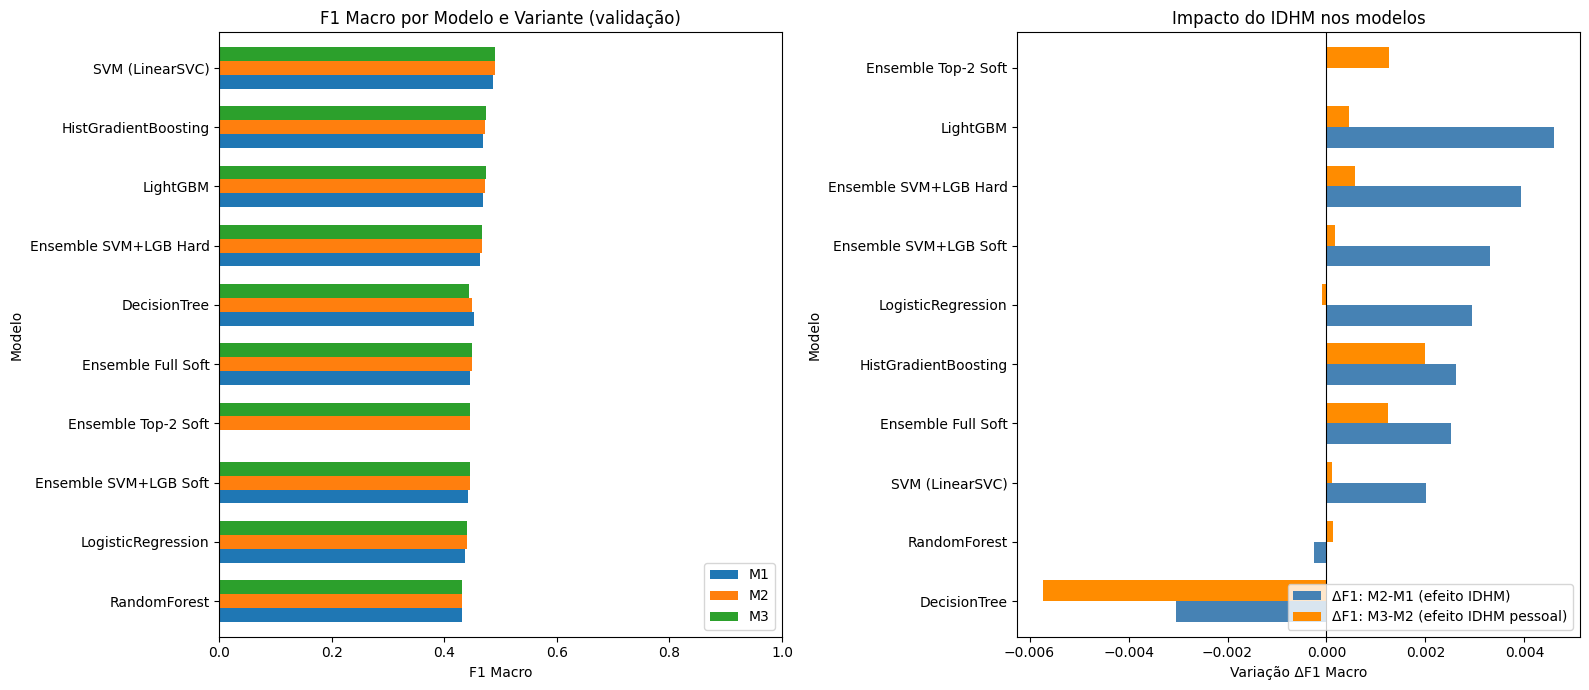


Top-5 por F1 Macro (validação):
Variante               Modelo  F1 Macro  F1 Weighted  Acurácia
      M3      SVM (LinearSVC)  0.489315     0.551803  0.554224
      M2      SVM (LinearSVC)  0.489194     0.551562  0.553958
      M1      SVM (LinearSVC)  0.487179     0.551358  0.553923
      M3 HistGradientBoosting  0.473683     0.578630  0.593496
      M3             LightGBM  0.473266     0.578620  0.593520


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Tabela pivô de F1 Macro
ax = axes[0]
pivot_sorted = pivot.loc[pivot.mean(axis=1).sort_values(ascending=True).index]
pivot_sorted.plot(kind='barh', ax=ax, width=0.7)
ax.set_xlabel('F1 Macro')
ax.set_title('F1 Macro por Modelo e Variante (validação)')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)

# Δ F1: efeito do IDHM e IDHM personalizado
ax2 = axes[1]
if 'M1' in pivot.columns and 'M2' in pivot.columns and 'M3' in pivot.columns:
    delta = pd.DataFrame({
        'ΔF1: M2-M1 (efeito IDHM)':      pivot['M2'] - pivot['M1'],
        'ΔF1: M3-M2 (efeito IDHM pessoal)': pivot['M3'] - pivot['M2'],
    })
    delta.sort_values('ΔF1: M2-M1 (efeito IDHM)', inplace=True)
    delta.plot(kind='barh', ax=ax2, width=0.7, color=['steelblue', 'darkorange'])
    ax2.axvline(0, color='k', linewidth=0.8)
    ax2.set_xlabel('Variação ΔF1 Macro')
    ax2.set_title('Impacto do IDHM nos modelos')
    ax2.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../data/processed/classificacao_resultados.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop-5 por F1 Macro (validação):')
print(df_res.nlargest(5, 'F1 Macro')[['Variante','Modelo','F1 Macro','F1 Weighted','Acurácia']].to_string(index=False))

## 6. Relatório detalhado do melhor modelo/variante

Melhor modelo: SVM (LinearSVC) (M3)

              precision    recall  f1-score   support

       Baixo       0.62      0.69      0.65    696506
       Medio       0.55      0.45      0.49    658941
        Alto       0.29      0.37      0.32    133324

    accuracy                           0.55   1488771
   macro avg       0.48      0.50      0.49   1488771
weighted avg       0.56      0.55      0.55   1488771



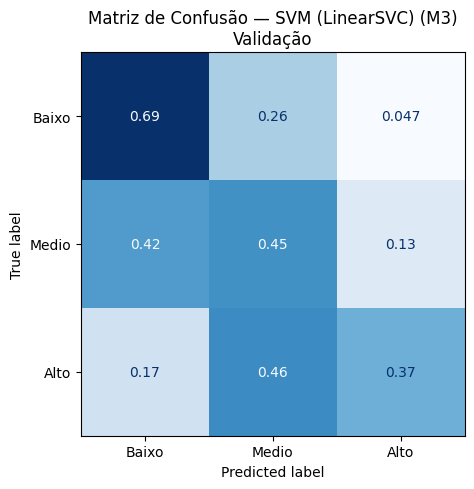

In [13]:
best_row   = df_res.loc[df_res['F1 Macro'].idxmax()]
best_nome  = best_row['Modelo']
best_var   = best_row['Variante']
best_model = all_trained[(best_nome, best_var)]

X_v_best = arrays[best_var][1]
y_pred_best = best_model.predict(X_v_best)

print(f'Melhor modelo: {best_nome} ({best_var})\n')
print(classification_report(y_val, y_pred_best, labels=CLASS_3, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_best, labels=CLASS_3,
    normalize='true', cmap='Blues', ax=ax, colorbar=False,
)
ax.set_title(f'Matriz de Confusão — {best_nome} ({best_var})\nValidação')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_val.png', dpi=120)
plt.show()

## 6b. Matrizes de Confusão — todos os modelos (melhor variante)

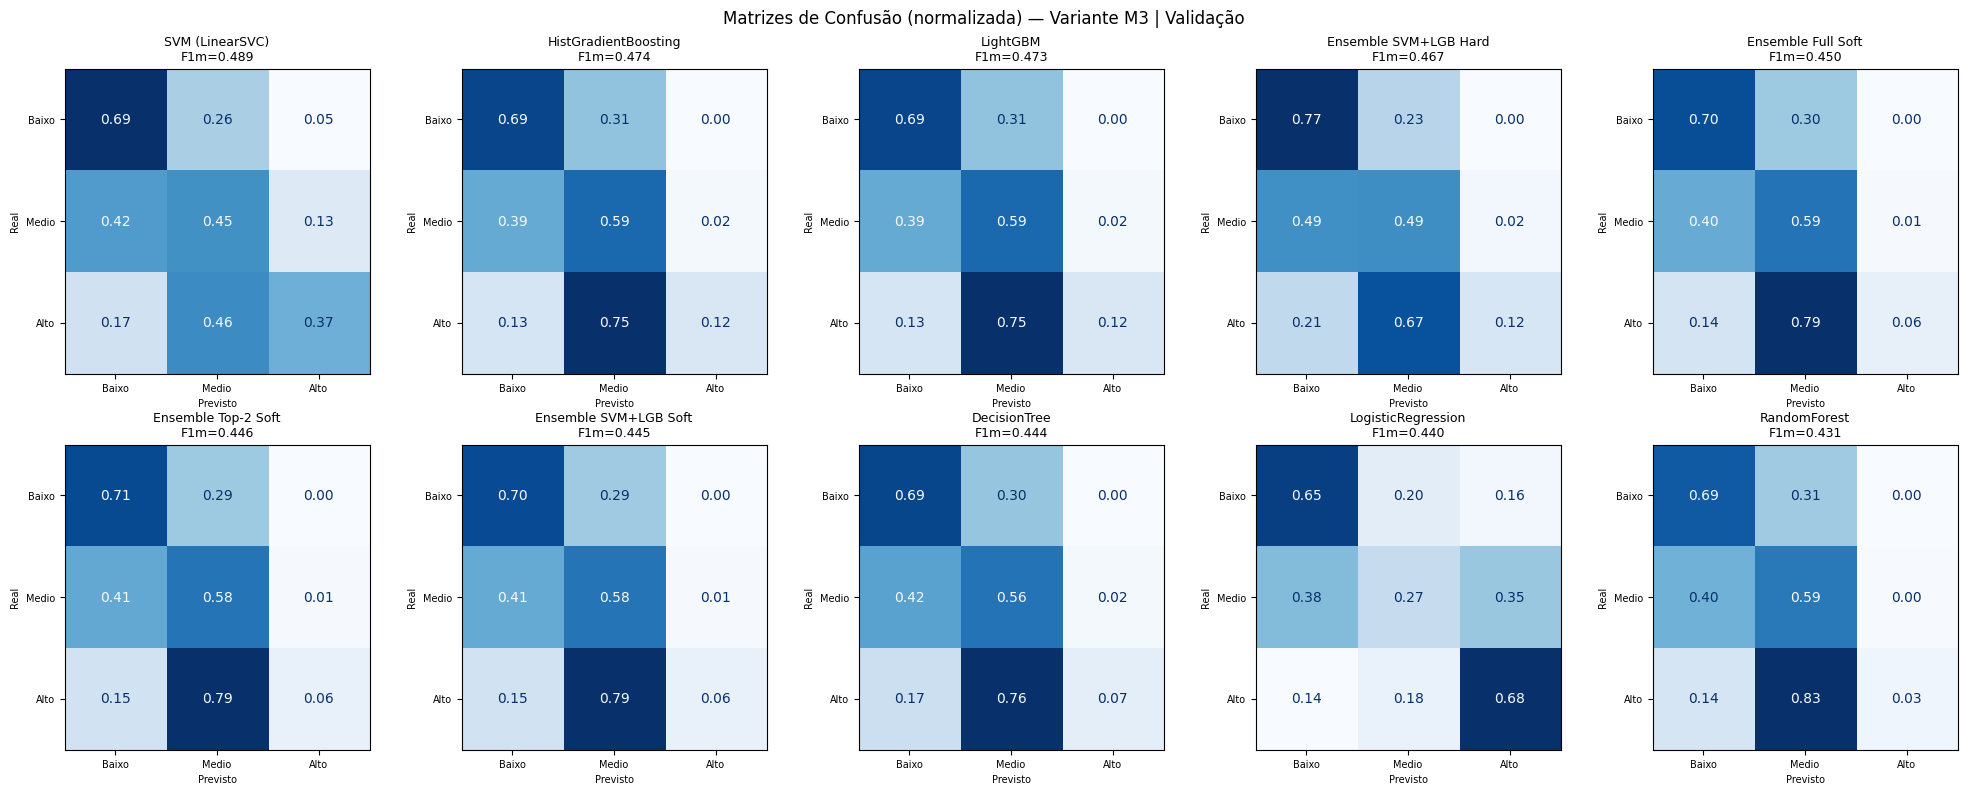

In [18]:
# Grade: todos os modelos × melhor variante
modelos_ordem = df_res[df_res['Variante'] == best_var].sort_values('F1 Macro', ascending=False)['Modelo'].tolist()
n_mod  = len(modelos_ordem)
n_cols = 5
n_rows = (n_mod + n_cols - 1) // n_cols

X_v_best = arrays[best_var][1]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.ravel()

for idx, nome in enumerate(modelos_ordem):
    ax  = axes[idx]
    m   = all_trained.get((nome, best_var))
    if m is None:
        ax.set_visible(False)
        continue
    yp  = m.predict(X_v_best)
    f1m = f1_score(y_val, yp, average='macro', labels=CLASS_3, zero_division=0)
    ConfusionMatrixDisplay.from_predictions(
        y_val, yp, labels=CLASS_3,
        normalize='true', cmap='Blues', ax=ax, colorbar=False,
        values_format='.2f',
    )
    ax.set_title(f'{nome}\nF1m={f1m:.3f}', fontsize=9)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xlabel('Previsto', fontsize=7)
    ax.set_ylabel('Real', fontsize=7)

for ax in axes[n_mod:]:
    ax.set_visible(False)

plt.suptitle(f'Matrizes de Confusão (normalizada) — Variante {best_var} | Validação', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices_todos.png', dpi=120, bbox_inches='tight')
plt.show()

## 6c. Matrizes de Confusão — melhor modelo × M1 / M2 / M3\n\nVisualiza o impacto de adicionar IDHM (M2) e IDHM personalizado (M3) no mesmo modelo.

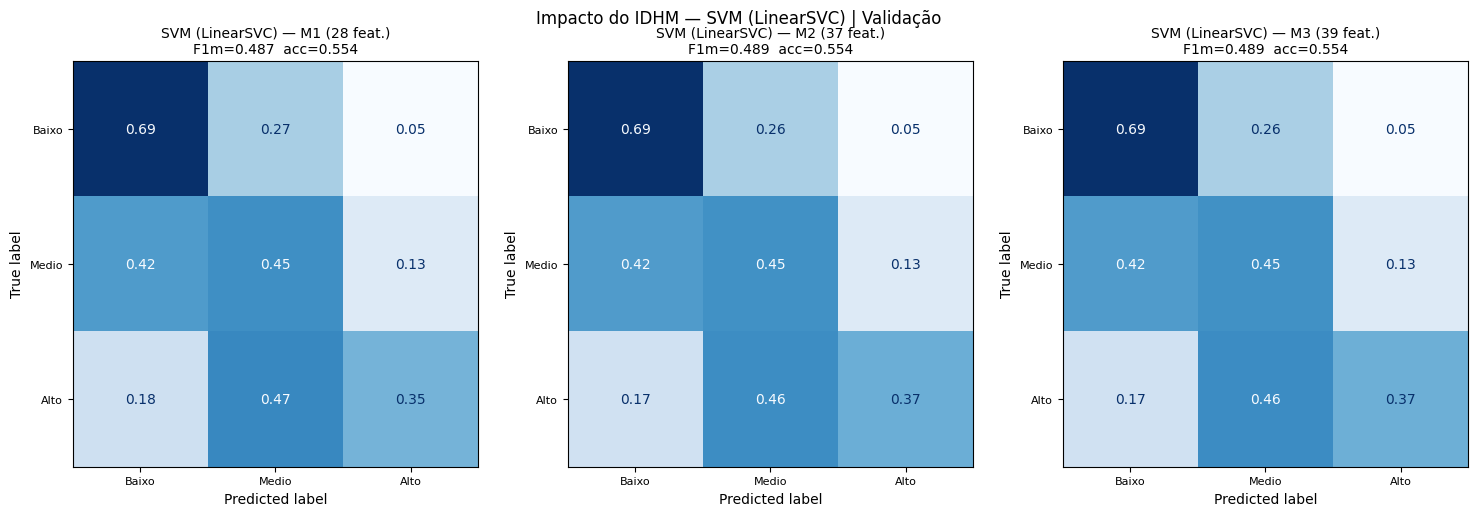

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, vname in zip(axes, ['M1', 'M2', 'M3']):
    m = all_trained.get((best_nome, vname))
    if m is None:
        ax.set_visible(False)
        continue
    X_v = arrays[vname][1]
    yp  = m.predict(X_v)
    f1m = f1_score(y_val, yp, average='macro', labels=CLASS_3, zero_division=0)
    acc = accuracy_score(y_val, yp)
    ConfusionMatrixDisplay.from_predictions(
        y_val, yp, labels=CLASS_3,
        normalize='true', cmap='Blues', ax=ax, colorbar=False,
        values_format='.2f',
    )
    n_feats = len(VARIANTS[vname])
    ax.set_title(f'{best_nome} — {vname} ({n_feats} feat.)\nF1m={f1m:.3f}  acc={acc:.3f}', fontsize=10)
    ax.tick_params(axis='both', labelsize=8)

plt.suptitle(f'Impacto do IDHM — {best_nome} | Validação', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_m1m2m3.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Importância das features

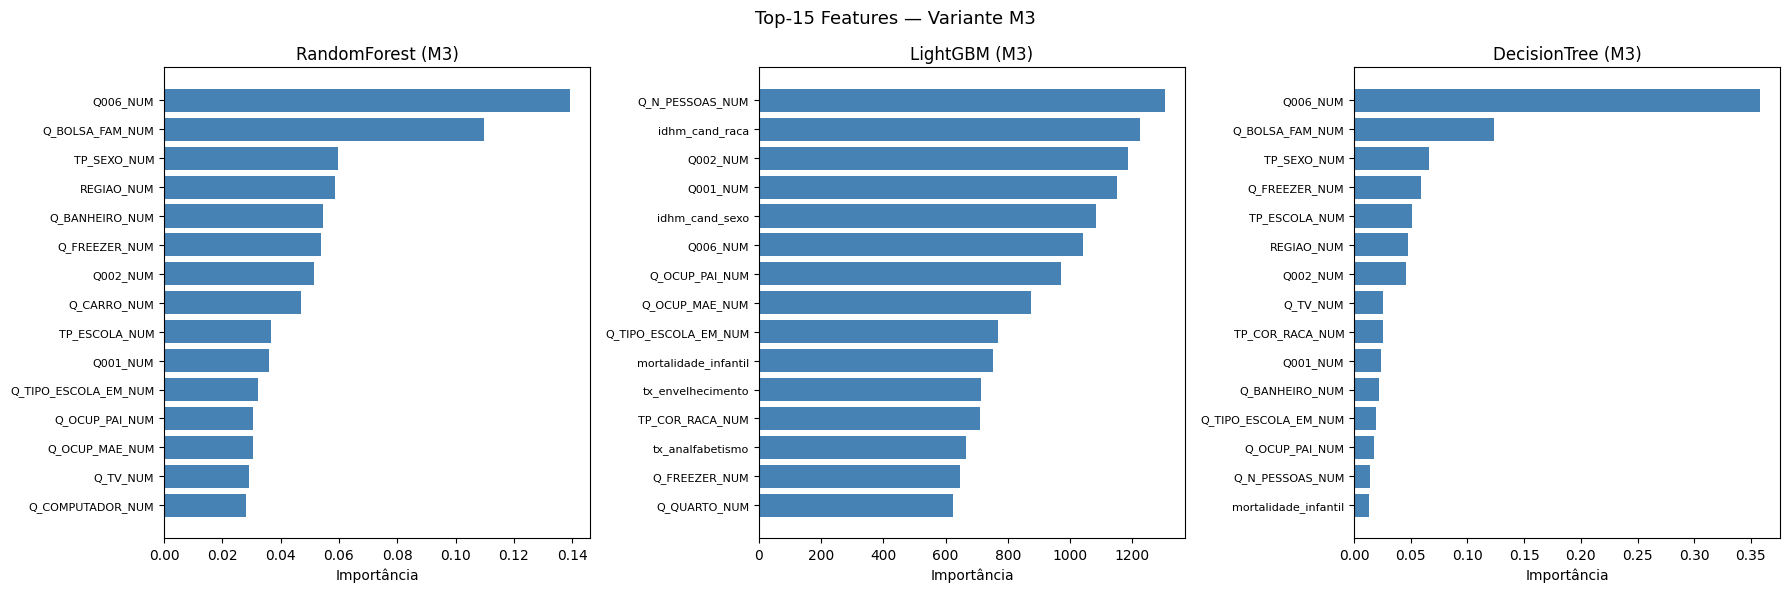

In [14]:
# Plot feature importance para modelos tree-based do melhor variante
tree_models = ['RandomForest', 'HistGradientBoosting', 'LightGBM',
               'DecisionTree', 'Ensemble Full Soft']
feats = VARIANTS[best_var]

fig, axes = plt.subplots(1, min(3, len(tree_models)), figsize=(18, 6))
axes = [axes] if len(tree_models) == 1 else list(axes)
ax_idx = 0

for nome in tree_models:
    if ax_idx >= len(axes): break
    m = all_trained.get((nome, best_var))
    if m is None: continue

    clf = m.named_steps['clf'] if hasattr(m, 'named_steps') else m

    if hasattr(clf, 'feature_importances_'):
        imp, label = clf.feature_importances_, 'Importância'
    elif hasattr(clf, 'estimators_'):   # VotingClassifier
        parts = []
        for _, est in clf.estimators_:
            sub = est.named_steps['clf'] if hasattr(est, 'named_steps') else est
            if hasattr(sub, 'feature_importances_'):
                parts.append(sub.feature_importances_)
        if not parts: continue
        imp, label = np.mean(parts, axis=0), 'Importância média'
        # imp pode ter tamanho diferente de len(feats) se algum sub-modelo usou feats diferentes
        if len(imp) != len(feats): continue
    else:
        continue

    ax = axes[ax_idx]
    top = np.argsort(imp)[::-1][:15]
    ax.barh([feats[i] for i in top[::-1]], imp[top[::-1]], color='steelblue')
    ax.set_title(f'{nome} ({best_var})')
    ax.set_xlabel(label)
    ax.tick_params(axis='y', labelsize=8)
    ax_idx += 1

plt.suptitle(f'Top-15 Features — Variante {best_var}', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Acurácia por região (hipótese H1)

In [15]:
REGIAO_MAP = {0: 'Norte', 1: 'Nordeste', 2: 'Centro-Oeste', 3: 'Sudeste', 4: 'Sul'}

df_ev = df_val[['REGIAO_NUM', 'FAIXA_3C']].copy()
df_ev['y_pred'] = y_pred_best
df_ev['acerto'] = (df_ev['y_pred'] == df_ev['FAIXA_3C']).astype(int)

acc_reg = (
    df_ev.dropna(subset=['REGIAO_NUM'])
    .groupby('REGIAO_NUM')['acerto']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Acurácia', 'count': 'N'})
)
acc_reg.index = acc_reg.index.map(REGIAO_MAP)
acc_reg['Acurácia'] = acc_reg['Acurácia'].apply(lambda x: f'{x:.3f}')
acc_reg['N']        = acc_reg['N'].apply(lambda x: f'{x:,}')
print(f'Acurácia por região — {best_nome} ({best_var}), validação:')
print(acc_reg.to_string())

Acurácia por região — SVM (LinearSVC) (M3), validação:
             Acurácia        N
REGIAO_NUM                    
Norte           0.633  162,381
Nordeste        0.579  537,742
Centro-Oeste    0.540  122,537
Sudeste         0.519  504,372
Sul             0.516  161,739


## 9. ⚠️ Conjunto de TESTE — SELADO

**Descomentar apenas na entrega final. Os dados de teste são fixos em `test_set.parquet`.**

In [16]:
# ── DESCOMENTE APENAS NA ENTREGA FINAL ──────────────────────────────────────
#
# X_te_best   = arrays[best_var][2]
# y_pred_test = best_model.predict(X_te_best)
# acc_test    = accuracy_score(y_test, y_pred_test)
# f1_test     = f1_score(y_test, y_pred_test, average='macro',
#                        labels=CLASS_3, zero_division=0)
# print(f'TESTE — {best_nome} ({best_var})')
# print(f'Acurácia: {acc_test:.4f}  |  F1 Macro: {f1_test:.4f}')
# print(classification_report(y_test, y_pred_test, labels=CLASS_3, zero_division=0))
#
# ─────────────────────────────────────────────────────────────────────────────
print('Teste selado. Descomentar somente na entrega final.')

Teste selado. Descomentar somente na entrega final.
